In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
import yaml
from tqdm import tqdm
import torchvision.transforms.v2 as v2
from copy import deepcopy
import sys
sys.path.append("/n/home11/sambt/phlab-neurips25")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

from models.litmodels import SimCLRModel
from models.networks import CustomResNet, MLP
from models.losses import MMDLoss, RBF
from data.datasets import CIFAR10Dataset
from data.cifar import CIFAR5MDataset
import data.data_utils as dutils

from sklearn.metrics import roc_auc_score, top_k_accuracy_score
from utils.plotting import make_corner
import os

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# model with class 1 held out

## evaluate model

In [2]:
N_cifar5m_load = 100_000
cifar = CIFAR10Dataset("resnet50",num_workers=2,batch_size=1024,exclude_classes=[])
cifar_train_dataset = cifar.train_dataset
cifar_test_dataset = cifar.test_dataset
cifar5m_full = CIFAR5MDataset("resnet50",[0],[(None,N_cifar5m_load)],grayscale=False,exclude_classes=[])

cifar_train_loader = DataLoader(cifar_train_dataset,batch_size=512,shuffle=True)
cifar_test_loader = DataLoader(cifar_test_dataset,batch_size=512,shuffle=True)
cifar5m_loader = DataLoader(cifar5m_full,batch_size=512,shuffle=True)

cifar10p1_data = np.load("cifar10.1_data/cifar10.1_v6_data.npy").transpose(0,3,1,2)
cifar10p1_labels = np.load("cifar10.1_data/cifar10.1_v6_labels.npy")
shuf = np.random.permutation(len(cifar10p1_labels))
cifar10p1_data = torch.tensor(cifar10p1_data[shuf])
cifar10p1_labels = torch.tensor(cifar10p1_labels[shuf])
transform = dutils.ResNet50Transform(resnet_type='resnet50',grayscale=False,from_pil=False)
cifar10p1_dataset = dutils.TransformDataset(transform,cifar10p1_data,cifar10p1_labels)
cifar10p1_loader = DataLoader(cifar10p1_dataset,batch_size=512,shuffle=False)

checkpoints = {
    1:"/n/home11/sambt/phlab-neurips25/runs/cifar10_simCLR_ResNet50_T0.1_withClassifier_dim8_exclude1/lightning_logs/8fuawffs/checkpoints/epoch=4-step=440.ckpt"
}
classes = sorted(list(checkpoints.keys()))

models = {l:SimCLRModel.load_from_checkpoint(checkpoints[l]).to(device) for l in classes}
outdirs = {}
for label in classes:
    outdir = f"embeddings_noShift_spaceWithClassifier/cifar_excludeClass{label}_dim8/"
    os.makedirs(outdir,exist_ok=True)
    outdirs[label] = outdir

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['encoder'])`.
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'projector' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['projector'])`.
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'classifier' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['classifier'])`.


In [3]:
embeds = {l:[] for l in classes}
labels = {l:[] for l in classes}
for batch in tqdm(cifar_train_loader):
    x,labs = batch
    for l in classes:
        with torch.no_grad():
            embeds[l].append(models[l].encoder(x.to(device)).cpu().numpy())
        labels[l].append(labs.numpy())
for l in classes:
    np.savez(f"{outdirs[l]}/cifar10_train.npz",
             data=np.concatenate(embeds[l]),
             labels=np.concatenate(labels[l]))
del embeds, labels
torch.cuda.empty_cache()

embeds = {l:[] for l in classes}
labels = {l:[] for l in classes}
for batch in tqdm(cifar_test_loader):
    x,labs = batch
    for l in classes:
        with torch.no_grad():
            embeds[l].append(models[l].encoder(x.to(device)).cpu().numpy())
        labels[l].append(labs.numpy())
for l in classes:
    np.savez(f"{outdirs[l]}/cifar10_test.npz",
             data=np.concatenate(embeds[l]),
             labels=np.concatenate(labels[l]))
del embeds, labels
torch.cuda.empty_cache()

embeds = {l:[] for l in classes}
labels = {l:[] for l in classes}
for batch in tqdm(cifar5m_loader):
    x,labs = batch
    for l in classes:
        with torch.no_grad():
            embeds[l].append(models[l].encoder(x.to(device)).cpu().numpy())
        labels[l].append(labs.numpy())
for l in classes:
    np.savez(f"{outdirs[l]}/cifar5m_N{N_cifar5m_load}.npz",
             data=np.concatenate(embeds[l]),
             labels=np.concatenate(labels[l]))
del embeds, labels
torch.cuda.empty_cache()

embeds = {l:[] for l in classes}
labels = {l:[] for l in classes}
for batch in tqdm(cifar10p1_loader):
    x,labs = batch
    for l in classes:
        with torch.no_grad():
            embeds[l].append(models[l].encoder(x.to(device)).cpu().numpy())
        labels[l].append(labs.numpy())
for l in classes:
    np.savez(f"{outdirs[l]}/cifar10.1.npz",
             data=np.concatenate(embeds[l]),
             labels=np.concatenate(labels[l]))
del embeds, labels
torch.cuda.empty_cache()

100%|██████████| 4/4 [00:05<00:00,  1.25s/it]


## Supervised classifier training on class 1 vs rest (train on cifar10 train set, test on cifar10 reference vs cifar5m test with cifar5m class 1 injected)

In [4]:
from sklearn.model_selection import train_test_split
data = np.load("embeddings_noShift_spaceWithClassifier/cifar_excludeClass1_dim8/cifar10_train.npz")
bkg_train = data['data'][data['labels'] != 1]
sig_train = data['data'][data['labels'] == 1]
np.random.shuffle(bkg_train)
np.random.shuffle(sig_train)

data = np.load("embeddings_noShift_spaceWithClassifier/cifar_excludeClass1_dim8/cifar5m_N100000.npz")
bkg_test = data['data'][data['labels'] != 1][:50000]
sig_test = data['data'][data['labels'] == 1][:10000]
np.random.shuffle(bkg_test)
np.random.shuffle(sig_test)

train_data = np.concatenate([bkg_train[:len(sig_train)],sig_train],axis=0)
train_labels = np.concatenate([np.zeros(len(bkg_train[:len(sig_train)])),np.ones(len(sig_train))]).reshape(-1,1)
perm = np.random.permutation(len(train_data))
train_data = train_data[perm]
train_labels = train_labels[perm]

train_data, val_data, train_labels, val_labels = train_test_split(train_data,train_labels,test_size=0.1)

train_dset = TensorDataset(torch.tensor(train_data).float(),torch.tensor(train_labels).float())
val_dset = TensorDataset(torch.tensor(val_data).float(),torch.tensor(val_labels).float())
train_loader = DataLoader(train_dset,batch_size=512,shuffle=True)
val_loader = DataLoader(val_dset,batch_size=512,shuffle=True)


# reference set
data = np.load("embeddings_noShift_spaceWithClassifier/cifar_excludeClass1_dim8/cifar10_test.npz")
ref = data['data'][data['labels'] != 1]

 67%|██████▋   | 67/100 [00:12<00:05,  5.51it/s]


stopped improving


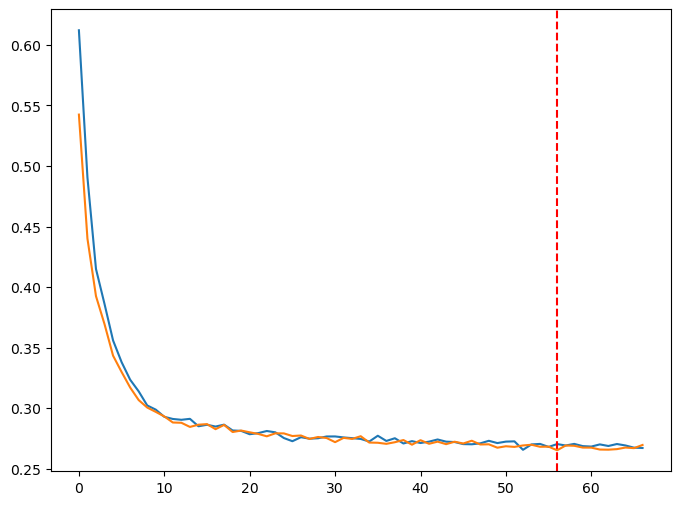

In [16]:
model = MLP(train_data.shape[1],[32,32,16],1,dropout=0.1).to(device)
num_epochs = 100
lr = 1e-3
optimizer = torch.optim.AdamW(model.parameters(),lr=lr)

train_loss = []
val_loss = []
best_loss = 1e6
best_state = None
best_ep = None
patience = 0
patience_lim = 10
for i in tqdm(range(num_epochs)):
    tlosses = []
    if patience == patience_lim:
        print('stopped improving')
        break
    for batch in train_loader:
        x,lab = batch
        preds = model(x.to(device))
        loss = F.binary_cross_entropy_with_logits(preds,lab.to(device))
        tlosses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss.append(np.mean(tlosses))
    
    vlosses = []
    for batch in train_loader:
        x,lab = batch
        with torch.no_grad():
            preds = model(x.to(device))
        loss = F.binary_cross_entropy_with_logits(preds,lab.to(device))
        vlosses.append(loss.item())
    val_loss.append(np.mean(vlosses))
    if val_loss[-1] < best_loss:
        best_loss = val_loss[-1]
        best_state = model.state_dict()
        best_ep = i
        patience = 0
    else:
        patience += 1

plt.figure(figsize=(8,6))
x = np.arange(len(train_loss))
plt.plot(x,train_loss,label='train')
plt.plot(x,val_loss,label='val')
plt.axvline(best_ep,linestyle='--',color='red')

model.load_state_dict(best_state)
model = model.eval()
torch.save(model,"cifar10SpaceWithoutClass1_classifier_trainedCIFAR10TrainSet_signalLabel1_dim8.pt")

In [17]:
act = nn.Sigmoid()
bkg_test_preds = []
for x, in DataLoader(TensorDataset(torch.tensor(bkg_test).float()),batch_size=512,shuffle=False):
    with torch.no_grad():
        bkg_test_preds.append(act(model(x.to(device))).cpu().numpy()[:,0])
bkg_test_preds = np.concatenate(bkg_test_preds)

sig_test_preds = []
for x, in DataLoader(TensorDataset(torch.tensor(sig_test).float()),batch_size=512,shuffle=False):
    with torch.no_grad():
        sig_test_preds.append(act(model(x.to(device))).cpu().numpy()[:,0])
sig_test_preds = np.concatenate(sig_test_preds)

ref_preds = []
for x, in DataLoader(TensorDataset(torch.tensor(ref).float()),batch_size=512,shuffle=False):
    with torch.no_grad():
        ref_preds.append(act(model(x.to(device))).cpu().numpy()[:,0])
ref_preds = np.concatenate(ref_preds)

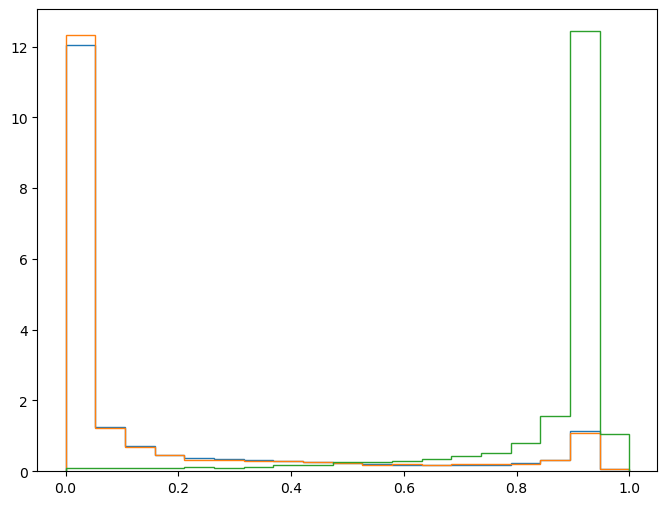

In [18]:
plt.figure(figsize=(8,6))
bins = np.linspace(0,1,20)
h1 = plt.hist(bkg_test_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(ref_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(sig_test_preds,bins=bins,density=True,histtype='step')

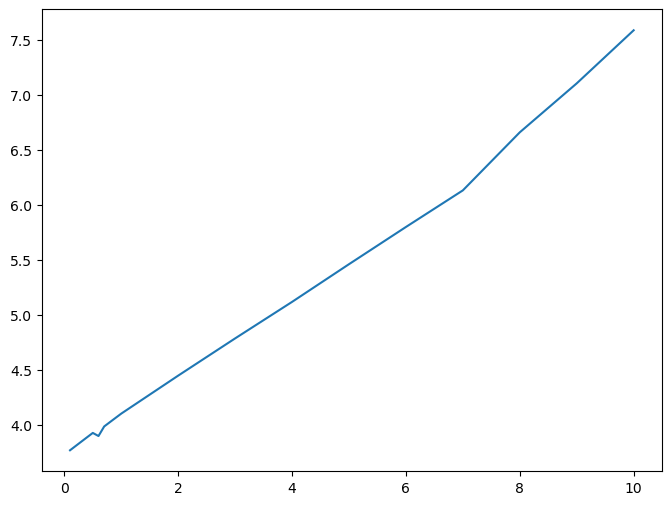

In [19]:
from scipy.stats import ks_2samp, norm
bkg_ref = ref_preds
bkg_inj = bkg_test_preds[:1800]

sig_fracs = [0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,
             0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
             0.1,0.15,0.2]
pvalues = []
zscores = []
for sf in sig_fracs:
    sig_sel = np.random.choice(sig_test_preds,size=int(sf*len(bkg_inj)),replace=False)
    tot = np.concatenate([bkg_inj,sig_sel])
    res = ks_2samp(bkg_ref,tot)
    pvalues.append(res.pvalue)
    zscores.append(norm.ppf(1-res.pvalue))

plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)

np.savez("cifar10SpaceWithoutClass1_T0.1_idealZscores_ks2sided_nref9k_nbkg1.8k_anomClass1_trainedCIFAR10_dim8.npz",zscores=np.array(zscores),fracs=np.array(sig_fracs))

In [20]:
from scipy.stats import chi2, norm
from utils.fitting import dLL

sig_fracs = [0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,
             0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
             0.1,0.12]
iNBkg = 1800
Ntoys = 1000
iNBins = 100

pvalues = []
psigmas = []
zscores = []
zsigmas = []
for sf in tqdm(sig_fracs):
    ps = []
    zs = []
    for i in range(Ntoys):
        iNSig = int(sf*iNBkg)
        iBkg = np.random.choice(bkg_test_preds,size=iNBkg,replace=False)
        iRef = ref_preds
        iSig = np.random.choice(sig_test_preds,size=iNSig,replace=False)
        iData = np.concatenate([iBkg,iSig])
        
        t = dLL(iData,iRef,sig_test_preds,iNSig,iNBkg,iNBins=50)
        p = chi2.cdf(t, 1)
        z = norm.ppf(p)
        if np.isfinite(z) and not np.isnan(z):
            ps.append(p)
            zs.append(z)
    pvalues.append(np.mean(ps))
    psigmas.append(np.std(ps))
    zscores.append(np.mean(zs))
    zsigmas.append(np.std(zs))
pvalues = np.array(pvalues)
psigmas = np.array(psigmas)
zscores = np.array(zscores)
zsigmas = np.array(zsigmas)

100%|██████████| 20/20 [01:53<00:00,  5.68s/it]


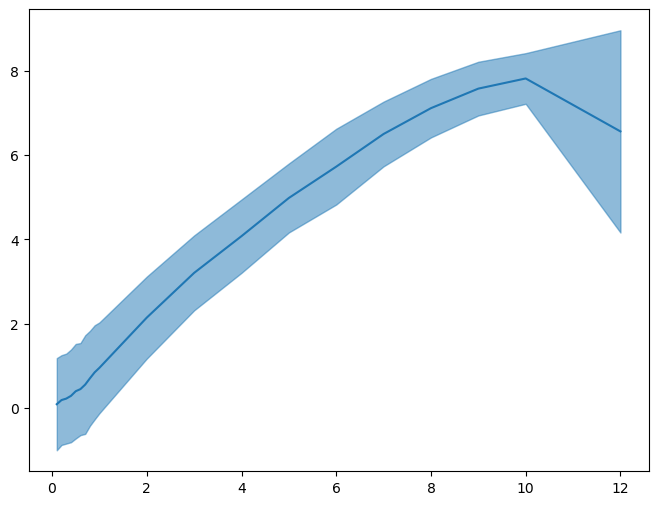

In [21]:
plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)
plt.fill_between(100*np.array(sig_fracs),zscores-zsigmas,zscores+zsigmas,color='C0',alpha=0.5)

In [22]:
np.savez("cifar10SpaceWithoutClass1_T0.1_idealZscores_LRtestWithFit_nbkg1.8k_anomClass1_trainedCIFAR10_dim8.npz",zscores=np.array(zscores),fracs=np.array(sig_fracs))

# model with no classes held out

## evaluate model

In [2]:
N_cifar5m_load = 100_000
cifar = CIFAR10Dataset("resnet50",num_workers=2,batch_size=1024,exclude_classes=[])
cifar_train_dataset = cifar.train_dataset
cifar_test_dataset = cifar.test_dataset
cifar5m_full = CIFAR5MDataset("resnet50",[0],[(None,N_cifar5m_load)],grayscale=False,exclude_classes=[])

cifar_train_loader = DataLoader(cifar_train_dataset,batch_size=512,shuffle=True)
cifar_test_loader = DataLoader(cifar_test_dataset,batch_size=512,shuffle=True)
cifar5m_loader = DataLoader(cifar5m_full,batch_size=512,shuffle=True)

cifar10p1_data = np.load("cifar10.1_data/cifar10.1_v6_data.npy").transpose(0,3,1,2)
cifar10p1_labels = np.load("cifar10.1_data/cifar10.1_v6_labels.npy")
shuf = np.random.permutation(len(cifar10p1_labels))
cifar10p1_data = torch.tensor(cifar10p1_data[shuf])
cifar10p1_labels = torch.tensor(cifar10p1_labels[shuf])
transform = dutils.ResNet50Transform(resnet_type='resnet50',grayscale=False,from_pil=False)
cifar10p1_dataset = dutils.TransformDataset(transform,cifar10p1_data,cifar10p1_labels)
cifar10p1_loader = DataLoader(cifar10p1_dataset,batch_size=512,shuffle=False)

checkpoint = "/n/home11/sambt/phlab-neurips25/runs/cifar10_simCLR_ResNet50_T0.1_withClassifier_dim8/lightning_logs/9gt9n9ki/checkpoints/epoch=5-step=588.ckpt"
model = SimCLRModel.load_from_checkpoint(checkpoint).to(device)
outdir = f"embeddings_noShift_spaceWithClassifier/cifar_allClasses_dim8/"
os.makedirs(outdir,exist_ok=True)

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['encoder'])`.
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'projector' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['projector'])`.
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'classifier' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['classifier'])`.


In [3]:
embeds = []
labels = []
for batch in tqdm(cifar_train_loader):
    x,labs = batch
    with torch.no_grad():
        embeds.append(model.encoder(x.to(device)).cpu().numpy())
    labels.append(labs.numpy())
np.savez(f"{outdir}/cifar10_train.npz",
         data=np.concatenate(embeds),
         labels=np.concatenate(labels))
del embeds, labels
torch.cuda.empty_cache()

embeds = []
labels = []
for batch in tqdm(cifar_test_loader):
    x,labs = batch
    with torch.no_grad():
        embeds.append(model.encoder(x.to(device)).cpu().numpy())
    labels.append(labs.numpy())
np.savez(f"{outdir}/cifar10_test.npz",
         data=np.concatenate(embeds),
         labels=np.concatenate(labels))
del embeds, labels
torch.cuda.empty_cache()

embeds = []
labels = []
for batch in tqdm(cifar5m_loader):
    x,labs = batch
    with torch.no_grad():
        embeds.append(model.encoder(x.to(device)).cpu().numpy())
    labels.append(labs.numpy())
np.savez(f"{outdir}/cifar5m_N{N_cifar5m_load}.npz",
         data=np.concatenate(embeds),
         labels=np.concatenate(labels))
del embeds, labels
torch.cuda.empty_cache()

embeds = []
labels = []
for batch in tqdm(cifar10p1_loader):
    x,labs = batch
    with torch.no_grad():
        embeds.append(model.encoder(x.to(device)).cpu().numpy())
    labels.append(labs.numpy())
np.savez(f"{outdir}/cifar10.1.npz",
         data=np.concatenate(embeds),
         labels=np.concatenate(labels))
del embeds, labels
torch.cuda.empty_cache()

100%|██████████| 4/4 [00:04<00:00,  1.15s/it]


## Supervised classifier training on class 1 vs rest (train on cifar10 train set, test on cifar10 reference vs cifar5m test with cifar5m class 1 injected)

In [4]:
from sklearn.model_selection import train_test_split
data = np.load("embeddings_noShift_spaceWithClassifier/cifar_allClasses_dim8/cifar10_train.npz")
bkg_train = data['data'][data['labels'] != 1]
sig_train = data['data'][data['labels'] == 1]
np.random.shuffle(bkg_train)
np.random.shuffle(sig_train)

data = np.load("embeddings_noShift_spaceWithClassifier/cifar_allClasses_dim8/cifar5m_N100000.npz")
bkg_test = data['data'][data['labels'] != 1][:50000]
sig_test = data['data'][data['labels'] == 1][:10000]
np.random.shuffle(bkg_test)
np.random.shuffle(sig_test)

train_data = np.concatenate([bkg_train[:len(sig_train)],sig_train],axis=0)
train_labels = np.concatenate([np.zeros(len(bkg_train[:len(sig_train)])),np.ones(len(sig_train))]).reshape(-1,1)
perm = np.random.permutation(len(train_data))
train_data = train_data[perm]
train_labels = train_labels[perm]

train_data, val_data, train_labels, val_labels = train_test_split(train_data,train_labels,test_size=0.1)

train_dset = TensorDataset(torch.tensor(train_data).float(),torch.tensor(train_labels).float())
val_dset = TensorDataset(torch.tensor(val_data).float(),torch.tensor(val_labels).float())
train_loader = DataLoader(train_dset,batch_size=512,shuffle=True)
val_loader = DataLoader(val_dset,batch_size=512,shuffle=True)


# reference set
data = np.load("embeddings_noShift_spaceWithClassifier/cifar_allClasses_dim8/cifar10_test.npz")
ref = data['data'][data['labels'] != 1]

 54%|█████▍    | 54/100 [00:13<00:11,  4.02it/s]


stopped improving


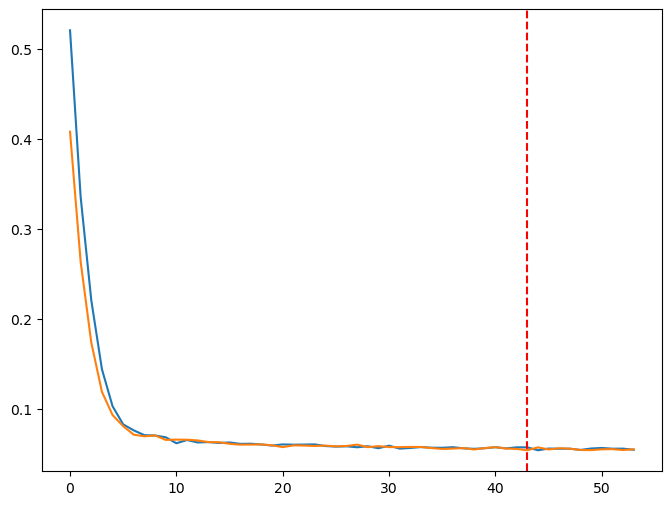

In [5]:
model = MLP(train_data.shape[1],[32,32],1,dropout=0.1).to(device)
num_epochs = 100
lr = 1e-3
optimizer = torch.optim.AdamW(model.parameters(),lr=lr)

train_loss = []
val_loss = []
best_loss = 1e6
best_state = None
best_ep = None
patience = 0
patience_lim = 10
for i in tqdm(range(num_epochs)):
    tlosses = []
    if patience == patience_lim:
        print('stopped improving')
        break
    for batch in train_loader:
        x,lab = batch
        preds = model(x.to(device))
        loss = F.binary_cross_entropy_with_logits(preds,lab.to(device))
        tlosses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss.append(np.mean(tlosses))
    
    vlosses = []
    for batch in train_loader:
        x,lab = batch
        with torch.no_grad():
            preds = model(x.to(device))
        loss = F.binary_cross_entropy_with_logits(preds,lab.to(device))
        vlosses.append(loss.item())
    val_loss.append(np.mean(vlosses))
    if val_loss[-1] < best_loss:
        best_loss = val_loss[-1]
        best_state = model.state_dict()
        best_ep = i
        patience = 0
    else:
        patience += 1

plt.figure(figsize=(8,6))
x = np.arange(len(train_loss))
plt.plot(x,train_loss,label='train')
plt.plot(x,val_loss,label='val')
plt.axvline(best_ep,linestyle='--',color='red')

model.load_state_dict(best_state)
model = model.eval()
torch.save(model,"cifar10AllClassSpace_classifier_trainedCIFAR10TrainSet_signalLabel1_dim8.pt")

In [6]:
act = nn.Sigmoid()
bkg_test_preds = []
for x, in DataLoader(TensorDataset(torch.tensor(bkg_test).float()),batch_size=512,shuffle=False):
    with torch.no_grad():
        bkg_test_preds.append(act(model(x.to(device))).cpu().numpy()[:,0])
bkg_test_preds = np.concatenate(bkg_test_preds)

sig_test_preds = []
for x, in DataLoader(TensorDataset(torch.tensor(sig_test).float()),batch_size=512,shuffle=False):
    with torch.no_grad():
        sig_test_preds.append(act(model(x.to(device))).cpu().numpy()[:,0])
sig_test_preds = np.concatenate(sig_test_preds)

ref_preds = []
for x, in DataLoader(TensorDataset(torch.tensor(ref).float()),batch_size=512,shuffle=False):
    with torch.no_grad():
        ref_preds.append(act(model(x.to(device))).cpu().numpy()[:,0])
ref_preds = np.concatenate(ref_preds)

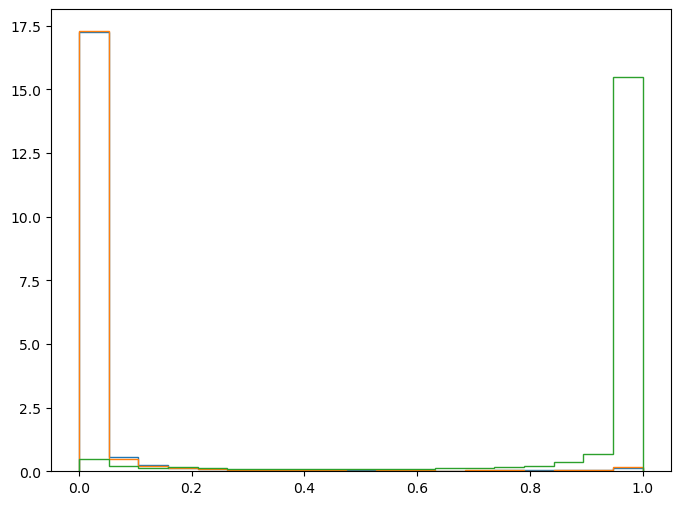

In [7]:
plt.figure(figsize=(8,6))
bins = np.linspace(0,1,20)
h1 = plt.hist(bkg_test_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(ref_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(sig_test_preds,bins=bins,density=True,histtype='step')

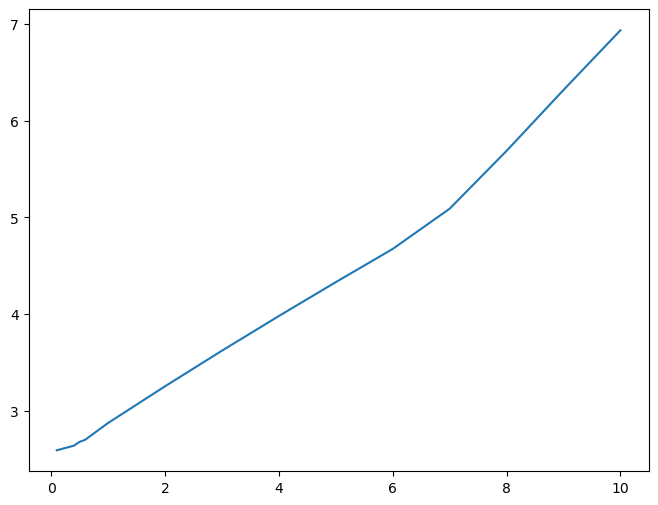

In [9]:
from scipy.stats import ks_2samp, norm
bkg_ref = ref_preds
bkg_inj = bkg_test_preds[:1800]

sig_fracs = [0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,
             0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
             0.1,0.15,0.2]
pvalues = []
zscores = []
for sf in sig_fracs:
    sig_sel = np.random.choice(sig_test_preds,size=int(sf*len(bkg_inj)),replace=False)
    tot = np.concatenate([bkg_inj,sig_sel])
    res = ks_2samp(bkg_ref,tot)
    pvalues.append(res.pvalue)
    zscores.append(norm.ppf(1-res.pvalue))

plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)

np.savez("cifar10AllClassSpace_T0.1_idealZscores_ks2sided_nref10k_nbkg10k_anomClass1_trainedCIFAR10_dim8.npz",zscores=np.array(zscores),fracs=np.array(sig_fracs))

In [10]:
from scipy.stats import chi2, norm
from utils.fitting import dLL

sig_fracs = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
             0.1,0.12]
iNBkg = 1800
Ntoys = 100
iNBins = 500

pvalues = []
psigmas = []
zscores = []
zsigmas = []
for sf in tqdm(sig_fracs):
    ps = []
    zs = []
    for i in range(Ntoys):
        iNSig = int(sf*iNBkg)
        iBkg = np.random.choice(bkg_test_preds,size=iNBkg,replace=False)
        iRef = ref_preds
        iSig = np.random.choice(sig_test_preds,size=iNSig,replace=False)
        iData = np.concatenate([iBkg,iSig])
        
        t = dLL(iData,iRef,sig_test_preds,iNSig,iNBkg,iNBins=50)
        p = chi2.cdf(t, 1)
        z = norm.ppf(p)
        if np.isfinite(z) and not np.isnan(z):
            ps.append(p)
            zs.append(z)
    pvalues.append(np.mean(ps))
    psigmas.append(np.std(ps))
    zscores.append(np.mean(zs))
    zsigmas.append(np.std(zs))
pvalues = np.array(pvalues)
psigmas = np.array(psigmas)
zscores = np.array(zscores)
zsigmas = np.array(zsigmas)

100%|██████████| 11/11 [00:08<00:00,  1.33it/s]


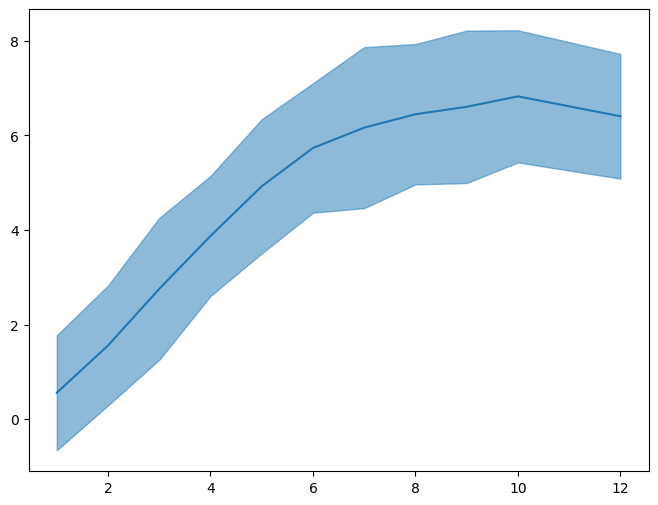

In [11]:
plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)
plt.fill_between(100*np.array(sig_fracs),zscores-zsigmas,zscores+zsigmas,color='C0',alpha=0.5)

In [12]:
np.savez("cifar10AllClassSpace_T0.1_idealZscores_LRtestWithFit_nbkg1.8k_anomClass1_trainedCIFAR10_dim8.npz",zscores=np.array(zscores),fracs=np.array(sig_fracs))
